In [67]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
#filtered_time = pd.read_csv("detrended.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
Next slips shape (4897, 8)
orig shape (5150, 8)


In [69]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-15 21:15:08,521] A new study created in memory with name: no-name-c061e1db-d113-4f55-9758-30ff1ed9dbf4
[I 2026-02-15 21:15:08,876] Trial 0 finished with value: 15604.204777519913 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 15604.204777519913.
[I 2026-02-15 21:15:09,063] Trial 1 finished with value: 14923.800657410755 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 1 with value: 14923.800657410755.
[I 2026-02-15 21:15:09,322] Trial 2 finished with value: 15176.705701960154 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 1 with value: 14923.800657410755.
[I 2026-02-15 21:15:09,484] Trial 3 finished with value: 15988.094298462342 a

Optimal Parameters: {'learning_rate': 0.010511157945449176, 'max_depth': 3, 'subsample': 0.602264195794888, 'colsample_bytree': 0.8159174287124199}
XGBoost Error: 13953.400599825807
Mean XGBoost Error: 9258.98722826087


282    56625.0
308    55155.0
486    35550.0
492    44835.0
456    35430.0
        ...   
217    39075.0
142    36360.0
552    52125.0
195    38445.0
477    32595.0
Name: time_to_next_ev_hr, Length: 115, dtype: float64
[57135.51  53435.184 37719.89  45288.758 44139.54  52529.297 56608.715
 48948.645 57014.707 51586.67  62607.566 56652.53  57746.094 38345.83
 58117.566 60983.094 57013.254 59075.18  37872.285 48178.367 52853.57
 38796.277 51950.66  59286.574 52825.543 52533.05  65751.28  41828.31
 56795.957 43277.062 59933.527 65106.65  47646.57  61853.645 44503.76
 59622.11  35151.395 58106.344 59722.51  33612.965 39517.863 44681.5
 45741.47  30015.186 64348.562 47945.273 45800.08  50475.14  56264.094
 60765.05  36500.996 59020.86  42806.777 42082.383 59858.95  28985.094
 28871.283 54688.004 55490.72  45502.344 43564.324 54559.74  47127.344
 61114.523 53023.39  43785.043 50705.83  56226.086 49807.938 49758.797
 61150.65  44732.816 50010.17  57903.953 41757.12  33327.797 31105.023
 65788

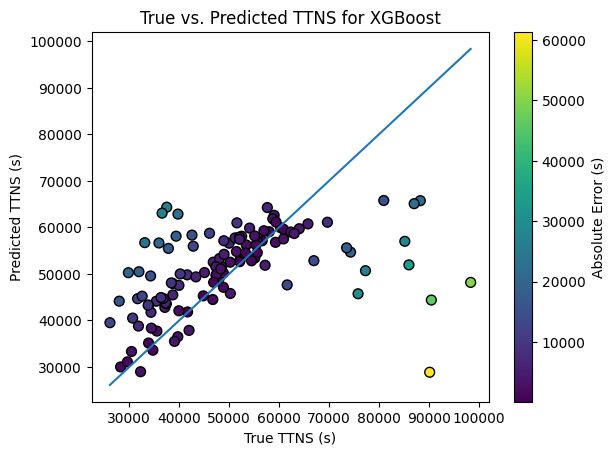

In [70]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

In [71]:
# Compute absolute errors
print("Length of Subset", len(XG_pred_secs))
diff = np.abs(XG_pred_secs - y_test_secs)

# Threshold for outliers
threshold = 20000  # adjust as needed

# Get indices of outliers in the test set
X_outliers = np.where(diff > threshold)[0]

print("Number of Outliers", len(X_outliers))
print(f"Outliers (error > {threshold}):")

# Print details for only outliers
for idx in X_outliers:
    true = y_test_secs.iloc[idx]   # pandas Series: use iloc
    pred = XG_pred_secs[idx]       # numpy array: use normal indexing
    print(f"Index position {idx}: True={true}, Predicted={pred}")

Length of Subset 115
Number of Outliers 15
Outliers (error > 20000):
Index position 8: True=85185.0, Predicted=57014.70703125
Index position 11: True=35955.0, Predicted=56652.53125
Index position 19: True=98370.0, Predicted=48178.3671875
Index position 22: True=86010.0, Predicted=51950.66015625
Index position 26: True=88290.0, Predicted=65751.28125
Index position 31: True=87060.0, Predicted=65106.6484375
Index position 42: True=75825.0, Predicted=45741.46875
Index position 44: True=37515.0, Predicted=64348.5625
Index position 56: True=90164.99999999999, Predicted=28871.283203125
Index position 66: True=77310.0, Predicted=50705.828125
Index position 83: True=29835.0, Predicted=50270.203125
Index position 84: True=33120.0, Predicted=56724.60546875
Index position 89: True=39765.0, Predicted=62868.953125
Index position 103: True=36585.0, Predicted=63073.9375
Index position 106: True=90495.0, Predicted=44390.50390625


XG Boost Drivers: tide_deriv     3937.818224
form_fac       2567.310711
time_since     2303.001255
tide_height    1639.113831
slip_size      1630.971462
high_t_evt      125.415814
dtype: float64


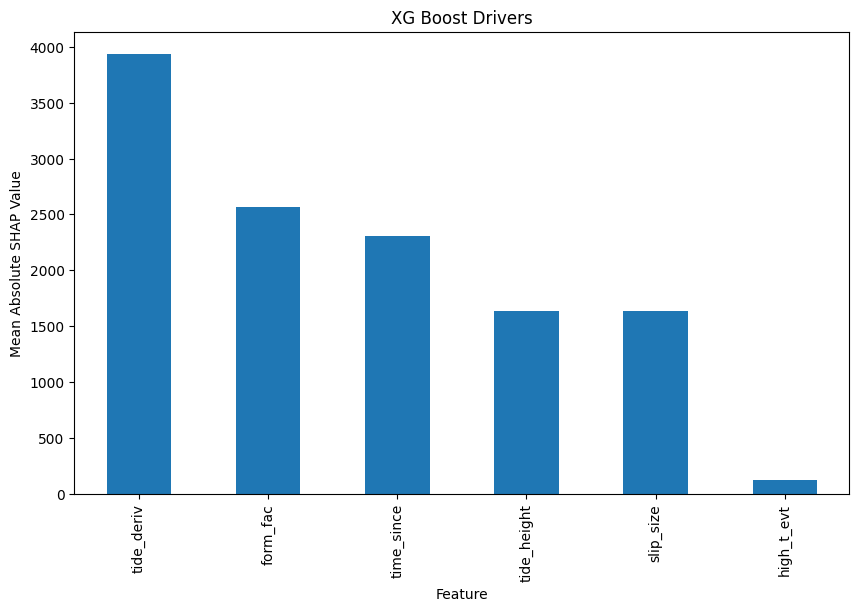

In [72]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
